# Banking Fraud Detection — Exploratory Data Analysis

Exploration of transaction patterns, class imbalance, distributions, outliers, and relationships relevant to fraud detection.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/financial_fraud_dataset.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (10000, 10)


In [50]:
#The distribution of fraudulent and legitimate transactions is examined to understand the class balance in the dataset.     

fraud_counts = df["is_fraud"].value_counts()

print("Transaction counts:")
print(fraud_counts)

print("\nFraud percentages:")
print((df["is_fraud"].value_counts(normalize=True) * 100).round(2))

Transaction counts:
is_fraud
0    9812
1     188
Name: count, dtype: int64

Fraud percentages:
is_fraud
0    98.12
1     1.88
Name: proportion, dtype: float64


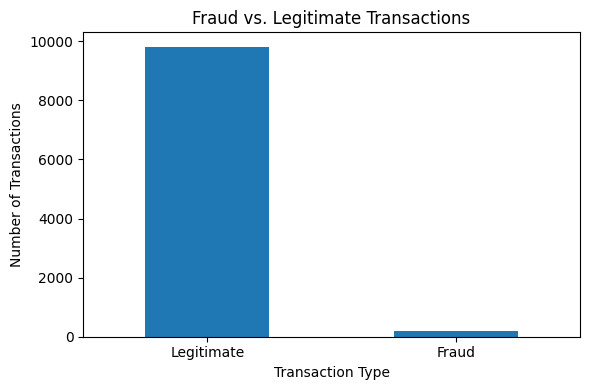

In [51]:
#The class distribution is visualized to clearly show the imbalance between legitimate and fraudulent transactions.
plt.figure(figsize=(6, 4))

df["is_fraud"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xticks([0, 1], ["Legitimate", "Fraud"], rotation=0)
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.title("Fraud vs. Legitimate Transactions")
plt.tight_layout()
plt.show()

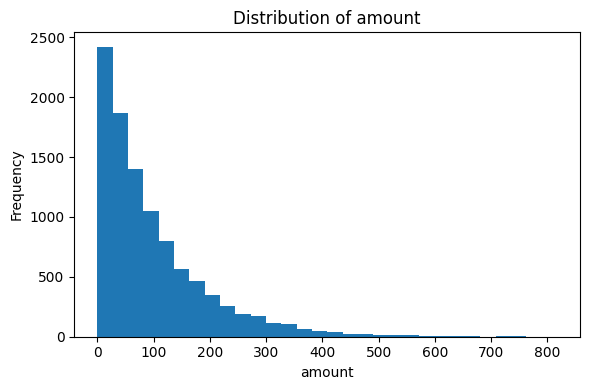

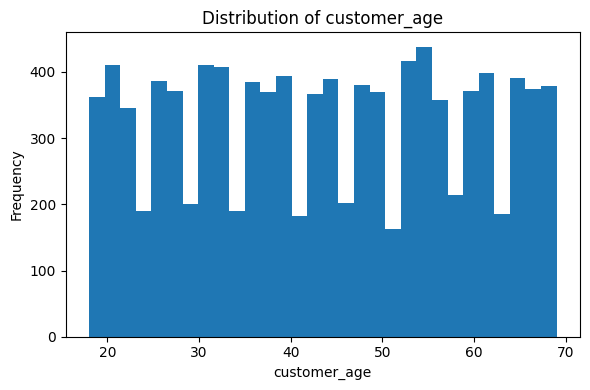

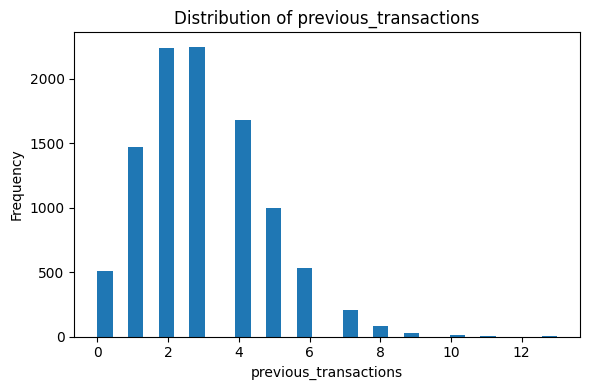

In [52]:
#The distributions of numerical transaction features are examined to understand their range and variation.

numerical_features = [
    "amount",
    "customer_age",
    "previous_transactions"
]

for column in numerical_features:
    plt.figure(figsize=(6, 4))
    plt.hist(df[column], bins=30)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {column}")
    plt.tight_layout()
    plt.show()

1. Transaction amounts are concentrated at lower values, with fewer high-value transactions creating a right-skewed distribution. 
2. Customer ages are broadly distributed from approximately 18 to 70 years, without a strong concentration toward a single age range.
3. The number of previous transactions is concentrated mainly between 2 and 5, with relatively few observations having higher transaction histories.

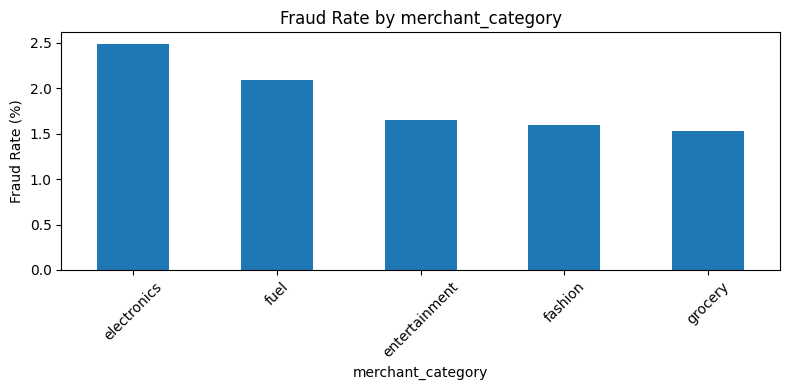

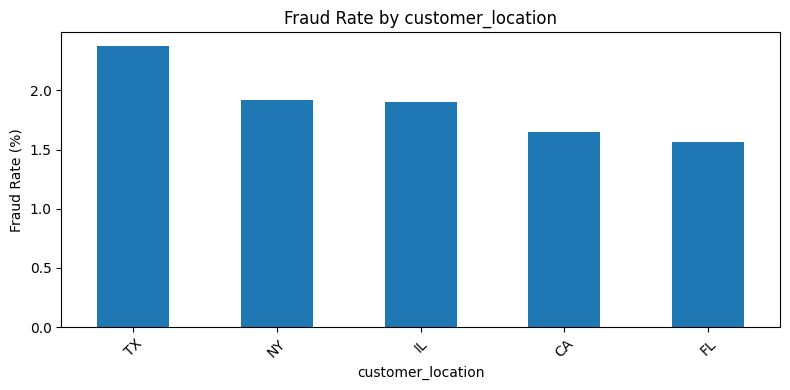

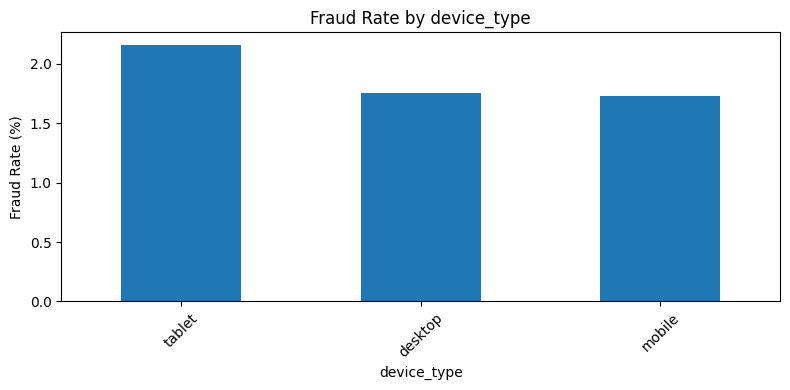

In [53]:
#The fraud rate is analyzed across merchant categories, customer locations, and device types to identify differences in fraud occurrence among categorical groups.

categorical_features = [
    "merchant_category",
    "customer_location",
    "device_type"
]

for column in categorical_features:
    fraud_rate = (
        df.groupby(column)["is_fraud"]
        .mean()
        .sort_values(ascending=False) * 100
    )

    plt.figure(figsize=(8, 4))
    fraud_rate.plot(kind="bar")

    plt.xlabel(column)
    plt.ylabel("Fraud Rate (%)")
    plt.title(f"Fraud Rate by {column}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

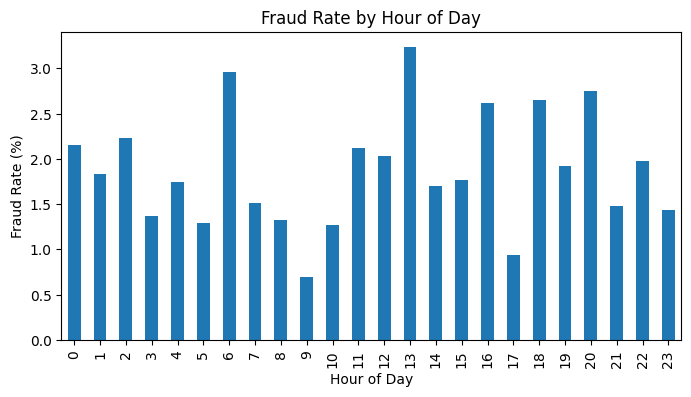

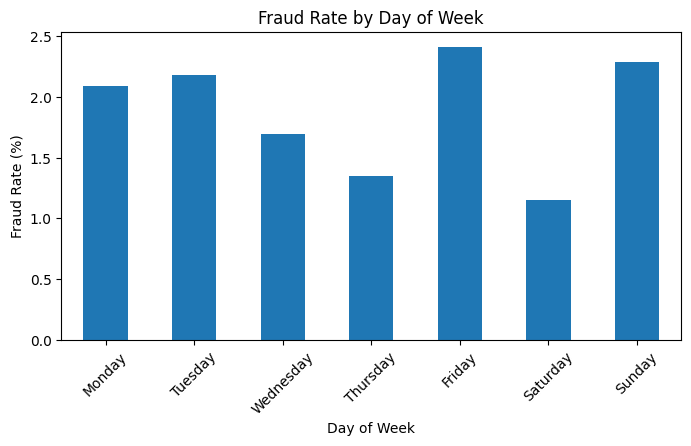

In [54]:
#The relationship between transaction time and fraud occurrence is explored using the hour of the day and day of the week derived from the transaction timestamp.

df["timestamp"] = pd.to_datetime(df["timestamp"])

df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.day_name()

fraud_by_hour = df.groupby("hour")["is_fraud"].mean() * 100

plt.figure(figsize=(8, 4))
fraud_by_hour.plot(kind="bar")

plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Hour of Day")
plt.show()


day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

fraud_by_day = (
    df.groupby("day_of_week")["is_fraud"]
    .mean()
    .reindex(day_order) * 100
)

plt.figure(figsize=(8, 4))
fraud_by_day.plot(kind="bar")

plt.xlabel("Day of Week")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Day of Week")
plt.xticks(rotation=45)
plt.show()

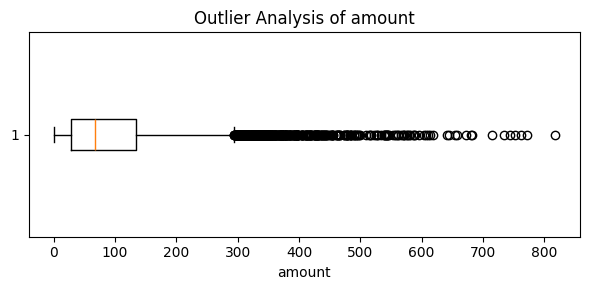

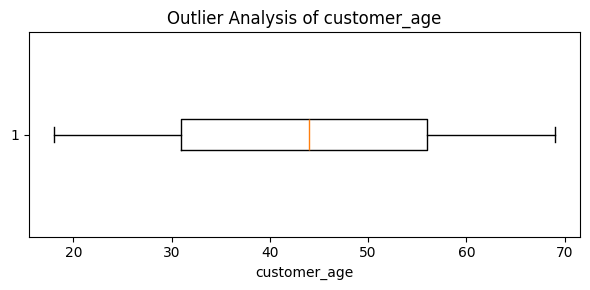

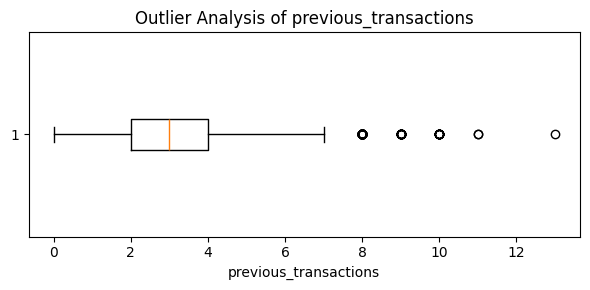

In [55]:

#Potential outliers in the numerical features are examined using box plots to identify unusually high or low observations.

numerical_features = [
    "amount",
    "customer_age",
    "previous_transactions"
]

for column in numerical_features:
    plt.figure(figsize=(6, 3))

    plt.boxplot(df[column], vert=False)

    plt.xlabel(column)
    plt.title(f"Outlier Analysis of {column}")
    plt.tight_layout()
    plt.show()

We identify potential outliers, but we don't remove them at this stage. That's important for our research because removing unusual transactions could potentially remove meaningful fraud-related behavior.

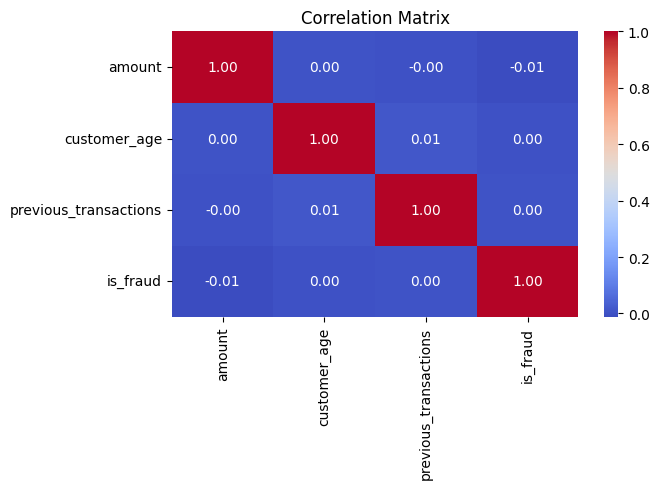

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df[
    ["amount", "customer_age", "previous_transactions", "is_fraud"]
].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

The correlation analysis shows that the numerical features have generally weak linear relationships with each other and with the fraud target. The diagonal values are 1.0 because each variable is perfectly correlated with itself. The low correlation values involving is_fraud indicate that no individual numerical feature has a strong linear association with fraud. However, low correlation does not imply that a feature is irrelevant, since machine-learning models can capture nonlinear relationships and interactions.

### Key EDA Findings

- The dataset contains a strong class imbalance, with fraudulent transactions representing a small minority of the observations.
- Transaction amounts are right-skewed, with several high-value observations.
- Customer age is broadly distributed without obvious statistical outliers.
- The number of previous transactions is concentrated at lower values, with a few higher-value observations.
- Fraud rates vary across merchant categories, customer locations, and device types.
- Fraud rates also vary across different hours of the day and days of the week, providing motivation for considering time-based features in later modeling.
- Outlier analysis identified potential high-value observations in transaction amount and a small number of high previous-transaction counts. These observations are retained because they may contain useful information for fraud detection.
- Correlation analysis shows generally weak linear relationships among the numerical features and with the fraud target.
- These exploratory findings provide the basis for the temporal validation and modeling stages of the project.